In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

In [2]:
tickers = ['SPY', 'TLT', 'GLD', 'EEM', 'VNQ']

In [3]:
data = yf.download(
    tickers,
    start="2020-01-01",
    auto_adjust = True
)['Close']

[*********************100%***********************]  5 of 5 completed


In [4]:
data.head()

Ticker,EEM,GLD,SPY,TLT,VNQ
Date,,,,,
2020-01-02,39.879772,143.949997,296.125275,112.001839,71.674110
2020-01-03,39.139332,145.860001,293.882935,113.726700,72.119629
2020-01-06,39.043499,147.389999,295.004089,113.080917,72.205597
2020-01-07,39.017372,147.970001,294.174591,112.525032,71.400551
2020-01-08,39.243855,146.860001,295.742493,111.781174,71.619408


In [5]:
data.tail()

Ticker,EEM,GLD,SPY,TLT,VNQ
Date,,,,,
2026-09-04,68.699997,406.769989,770.190002,82.209999,96.019997
2026-09-08,68.830002,399.720001,765.960022,82.199997,95.930000
2026-09-09,68.480003,403.350006,762.400024,81.730003,94.940002
2026-09-10,67.000000,396.359985,757.830017,80.779999,94.120003
2026-09-11,67.839996,398.769989,764.289978,80.870003,94.800003


In [6]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1682 entries, 2020-01-02 to 2026-09-11
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EEM     1682 non-null   float64
 1   GLD     1682 non-null   float64
 2   SPY     1682 non-null   float64
 3   TLT     1682 non-null   float64
 4   VNQ     1682 non-null   float64
dtypes: float64(5)
memory usage: 78.8 KB


In [7]:
data.isna().sum()

Ticker
EEM    0
GLD    0
SPY    0
TLT    0
VNQ    0
dtype: int64

In [8]:
returns = data.pct_change()

In [9]:
returns.head()

Ticker,EEM,GLD,SPY,TLT,VNQ
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.018567,0.013269,-0.007572,0.015400,0.006216
2020-01-06,-0.002449,0.010490,0.003815,-0.005678,0.001192
2020-01-07,-0.000669,0.003935,-0.002812,-0.004916,-0.011149
2020-01-08,0.005805,-0.007502,0.005330,-0.006611,0.003065


In [10]:
returns.isna().sum()

Ticker
EEM    1
GLD    1
SPY    1
TLT    1
VNQ    1
dtype: int64

In [11]:
returns.dropna(inplace=True)

In [12]:
returns.describe()

Ticker,EEM,GLD,SPY,TLT,VNQ
count,1681.000000,1681.000000,1681.000000,1681.000000,1681.000000
mean,0.000417,0.000675,0.000645,-0.000140,0.000277
std,0.014161,0.011660,0.012665,0.010387,0.014794
min,-0.124793,-0.102742,-0.109424,-0.066683,-0.177277
25%,-0.006418,-0.005059,-0.004613,-0.006464,-0.006610
50%,0.000772,0.000858,0.000906,-0.000122,0.000587
75%,0.007556,0.006911,0.006713,0.005808,0.007439
max,0.080529,0.063587,0.105019,0.075196,0.089966


In [13]:
cumulative_returns = (1 + returns).cumprod()

In [14]:
cumulative_returns.tail()

Ticker,EEM,GLD,SPY,TLT,VNQ
Date,,,,,
2026-09-04,1.722678,2.825773,2.600892,0.734006,1.339675
2026-09-08,1.725938,2.776798,2.586608,0.733916,1.338419
2026-09-09,1.717161,2.802015,2.574586,0.729720,1.324607
2026-09-10,1.680050,2.753456,2.559153,0.721238,1.313166
2026-09-11,1.701113,2.770198,2.580968,0.722042,1.322653


<Axes: xlabel='Date'>

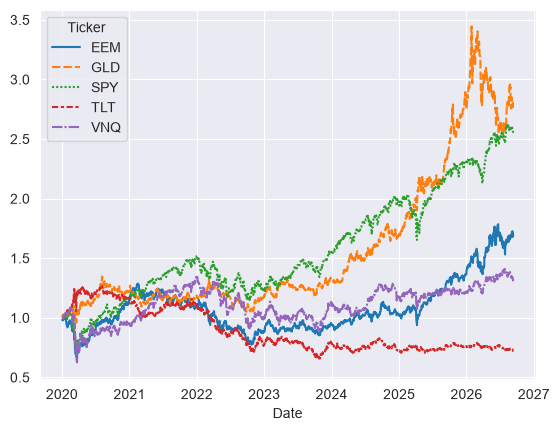

In [15]:
sns.lineplot(data=cumulative_returns)

In [16]:
running_max = cumulative_returns.cummax()

In [17]:
drawdown = cumulative_returns / running_max - 1

In [18]:
drawdown.min()

Ticker
EEM   -0.398223
GLD   -0.264045
SPY   -0.337173
TLT   -0.483511
VNQ   -0.423982
dtype: float64

In [19]:
summary = pd.DataFrame({
    'final_value': cumulative_returns.iloc[-1],
    'mean': returns.mean(),
    'std': returns.std(),
    'max_drawdown': drawdown.min()
})

In [20]:
summary['annual_mean'] = summary['mean'] * 252
summary['annual_volatility'] = summary['std'] * np.sqrt(252)

In [21]:
years = (data.index[-1] - data.index[0]).days / 365.25
summary['cagr'] = summary['final_value'] ** (1 / years) - 1

In [22]:
summary

,final_value,mean,std,max_drawdown,annual_mean,annual_volatility,cagr
Ticker,,,,,,,
EEM,1.701113,0.000417,0.014161,-0.398223,0.105062,0.224801,0.082636
GLD,2.770198,0.000675,0.011660,-0.264045,0.169996,0.185104,0.164480
SPY,2.580968,0.000645,0.012665,-0.337173,0.162437,0.201053,0.152232
TLT,0.722042,-0.000140,0.010387,-0.483511,-0.035243,0.164881,-0.047506
VNQ,1.322653,0.000277,0.014794,-0.423982,0.069839,0.234853,0.042677


In [23]:
correlation_matrix = returns.corr()

<Axes: xlabel='Ticker', ylabel='Ticker'>

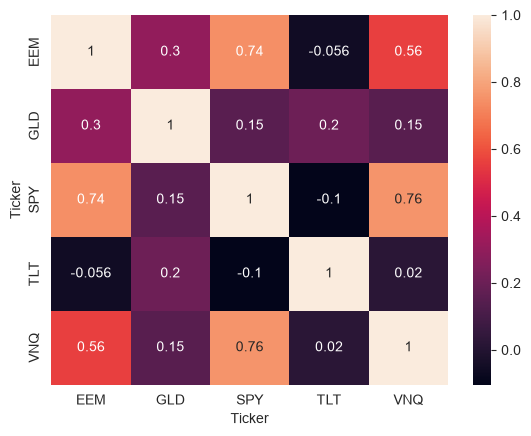

In [24]:
sns.heatmap(correlation_matrix, annot=True)

In [25]:
weights = np.array([0, 0, 0.5, 0.5, 0])

In [26]:
portfolio_returns = returns * weights

In [27]:
portfolio_returns.head()

Ticker,EEM,GLD,SPY,TLT,VNQ
Date,,,,,
2020-01-03,-0.0,0.0,-0.003786,0.007700,0.0
2020-01-06,-0.0,0.0,0.001907,-0.002839,0.0
2020-01-07,-0.0,0.0,-0.001406,-0.002458,-0.0
2020-01-08,0.0,-0.0,0.002665,-0.003305,0.0
2020-01-09,0.0,-0.0,0.003390,0.001755,-0.0


In [28]:
portfolio_returns.mean()

Ticker
EEM    0.000000
GLD    0.000000
SPY    0.000322
TLT   -0.000070
VNQ    0.000000
dtype: float64

In [29]:
portfolio_returns.std()

Ticker
EEM    0.000000
GLD    0.000000
SPY    0.006333
TLT    0.005193
VNQ    0.000000
dtype: float64

In [30]:
portfolio_returns['Portfolio'] = portfolio_returns.sum(axis=1)

In [31]:
portfolio_returns

Ticker,EEM,GLD,SPY,TLT,VNQ,Portfolio
Date,,,,,,
2020-01-03,-0.0,0.0,-0.003786,0.007700,0.0,0.003914
2020-01-06,-0.0,0.0,0.001907,-0.002839,0.0,-0.000932
2020-01-07,-0.0,0.0,-0.001406,-0.002458,-0.0,-0.003864
2020-01-08,0.0,-0.0,0.002665,-0.003305,0.0,-0.000640
2020-01-09,0.0,-0.0,0.003390,0.001755,-0.0,0.005145
...,...,...,...,...,...,...
2026-09-04,0.0,-0.0,-0.001927,0.000853,-0.0,-0.001074
2026-09-08,0.0,-0.0,-0.002746,-0.000061,-0.0,-0.002807
2026-09-09,-0.0,0.0,-0.002324,-0.002859,-0.0,-0.005183


In [32]:
portfolio_returns['Portfolio'].std() * np.sqrt(252)

np.float64(0.12321792950572467)

In [33]:
returns['SPY'].std() * np.sqrt(252)

np.float64(0.20105333674230264)

In [34]:
returns['TLT'].std() * np.sqrt(252)

np.float64(0.16488091867469545)

In [35]:
returns[['SPY', 'TLT']].corr()

Ticker,SPY,TLT
Ticker,,
SPY,1.000000,-0.103734
TLT,-0.103734,1.000000


In [36]:
(1 + portfolio_returns['Portfolio']).cumprod().iloc[-1]

np.float64(1.4528497012716786)

In [37]:
(1 + portfolio_returns['Portfolio']).cumprod().iloc[-1] ** (1 / years) - 1

np.float64(0.05741020371513805)

In [38]:
portfolio_cumulative_returns = (1 + portfolio_returns['Portfolio']).cumprod()

In [39]:
portfolio_running_max = portfolio_cumulative_returns.cummax()

In [40]:
portfolio_drawdown = portfolio_cumulative_returns / portfolio_running_max - 1

In [41]:
portfolio_final_value = portfolio_cumulative_returns.iloc[-1]

In [42]:
portfolio_final_value ** (1 / years) - 1

np.float64(0.05741020371513805)

In [43]:
portfolio_drawdown.min()

np.float64(-0.28498797539316256)

-----------------------------------------------------------------------------------------------------------------------------------------------

In [44]:
spy_weights = np.array([0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0])
tlt_weights = 1 - spy_weights
spy_tlt_weights = np.stack((spy_weights, tlt_weights), axis=1)

In [45]:
results = pd.DataFrame(columns=['SPY_weight', 'TLT_weight', 'CAGR', 'annual_volatility', 'max_drawdown'])

In [46]:
results

,SPY_weight,TLT_weight,CAGR,annual_volatility,max_drawdown


In [47]:
spy_tlt_returns = returns[['SPY', 'TLT']]

In [48]:
for spy_weight, tlt_weight in spy_tlt_weights:
    portfolio_returns = spy_tlt_returns * np.array([spy_weight, tlt_weight])
    portfolio_returns['Portfolio'] = portfolio_returns.sum(axis=1)
    
    portfolio_cumulative_returns = (portfolio_returns['Portfolio'] + 1).cumprod()
    portfolio_cagr = portfolio_cumulative_returns.iloc[-1] ** (1 / years) - 1
    
    portfolio_annual_volatility = portfolio_returns['Portfolio'].std() * np.sqrt(252)
    
    portfolio_running_max = portfolio_cumulative_returns.cummax()
    portfolio_drawdown = portfolio_cumulative_returns / portfolio_running_max - 1
    portfolio_max_drawdown = portfolio_drawdown.min()
    
    results.loc[len(results)] = [spy_weight, tlt_weight, portfolio_cagr, portfolio_annual_volatility, portfolio_max_drawdown]

In [49]:
results

,SPY_weight,TLT_weight,CAGR,annual_volatility,max_drawdown
0,0.0,1.0,-0.047506,0.164881,-0.483511
1,0.2,0.8,-0.004641,0.133848,-0.365533
2,0.4,0.6,0.037078,0.120846,-0.298753
3,0.5,0.5,0.057410,0.123218,-0.284988
4,0.6,0.4,0.077340,0.131344,-0.272353
5,0.8,0.2,0.115830,0.160802,-0.255382
6,1.0,0.0,0.152232,0.201053,-0.337173


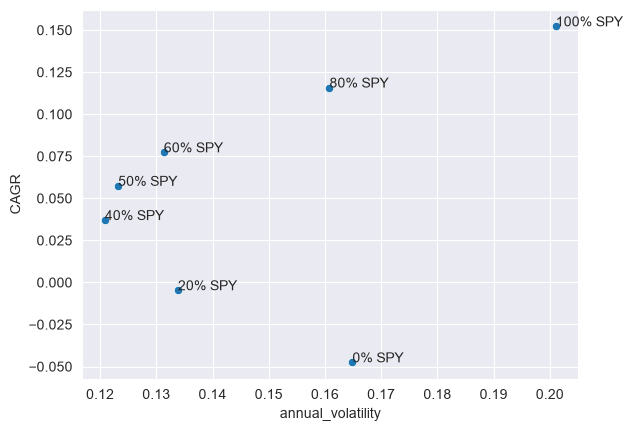

In [50]:
fig = sns.scatterplot(data=results, x='annual_volatility', y='CAGR')

for i in range (results.shape[0]):
    fig.text(
        results['annual_volatility'].iloc[i],
        results['CAGR'].iloc[i],
        f"{results['SPY_weight'].iloc[i]:.0%} SPY"
    )


In [51]:
spy_weights = np.linspace(0, 1, 101)
tlt_weights = 1 - spy_weights
spy_tlt_weights = np.stack((spy_weights, tlt_weights), axis=1)

In [52]:
spy_tlt_weights

array([[0.  , 1.  ],
       [0.01, 0.99],
       [0.02, 0.98],
       [0.03, 0.97],
       [0.04, 0.96],
       [0.05, 0.95],
       [0.06, 0.94],
       [0.07, 0.93],
       [0.08, 0.92],
       [0.09, 0.91],
       [0.1 , 0.9 ],
       [0.11, 0.89],
       [0.12, 0.88],
       [0.13, 0.87],
       [0.14, 0.86],
       [0.15, 0.85],
       [0.16, 0.84],
       [0.17, 0.83],
       [0.18, 0.82],
       [0.19, 0.81],
       [0.2 , 0.8 ],
       [0.21, 0.79],
       [0.22, 0.78],
       [0.23, 0.77],
       [0.24, 0.76],
       [0.25, 0.75],
       [0.26, 0.74],
       [0.27, 0.73],
       [0.28, 0.72],
       [0.29, 0.71],
       [0.3 , 0.7 ],
       [0.31, 0.69],
       [0.32, 0.68],
       [0.33, 0.67],
       [0.34, 0.66],
       [0.35, 0.65],
       [0.36, 0.64],
       [0.37, 0.63],
       [0.38, 0.62],
       [0.39, 0.61],
       [0.4 , 0.6 ],
       [0.41, 0.59],
       [0.42, 0.58],
       [0.43, 0.57],
       [0.44, 0.56],
       [0.45, 0.55],
       [0.46, 0.54],
       [0.47,

In [53]:
results = pd.DataFrame(columns=['SPY_weight', 'TLT_weight', 'annual_mean', 'annual_volatility'])
results

,SPY_weight,TLT_weight,annual_mean,annual_volatility


In [54]:
for spy_weight, tlt_weight in spy_tlt_weights:
    portfolio_returns = spy_tlt_returns * np.array([spy_weight, tlt_weight])
    portfolio_returns['Portfolio'] = portfolio_returns.sum(axis=1)
    
    portfolio_annual_mean = portfolio_returns['Portfolio'].mean() * 252
    
    portfolio_annual_volatility = portfolio_returns['Portfolio'].std() * np.sqrt(252)
    
    results.loc[len(results)] = [spy_weight, tlt_weight, portfolio_annual_mean, portfolio_annual_volatility]

In [55]:
results

,SPY_weight,TLT_weight,annual_mean,annual_volatility
0,0.00,1.00,-0.035243,0.164881
1,0.01,0.99,-0.033267,0.163036
2,0.02,0.98,-0.031290,0.161216
3,0.03,0.97,-0.029313,0.159422
4,0.04,0.96,-0.027336,0.157654
...,...,...,...,...
96,0.96,0.04,0.154530,0.192439
97,0.97,0.03,0.156506,0.194571
98,0.98,0.02,0.158483,0.196718
99,0.99,0.01,0.160460,0.198879


In [56]:
results['annual_volatility'].idxmin()

np.int64(41)

<Axes: xlabel='annual_volatility', ylabel='annual_mean'>

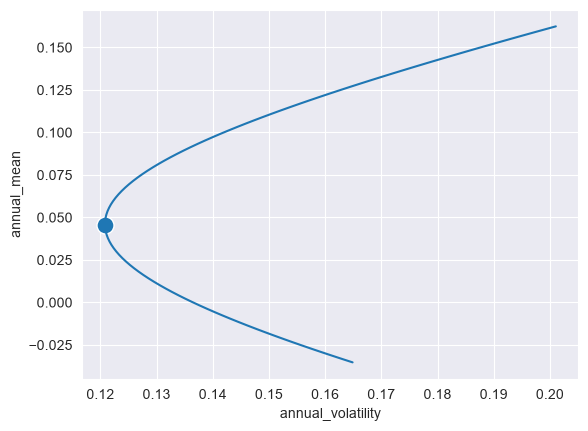

In [57]:
portfolio_min_annual_volatility = results['annual_volatility'].idxmin()

fig = sns.lineplot(
    data=results,
    x='annual_volatility',
    y='annual_mean',
    sort=False
)
sns.scatterplot(
    data = results.loc[[portfolio_min_annual_volatility]],
    x='annual_volatility',
    y='annual_mean',
    s=150
)


In [58]:
var_spy = returns[['SPY', 'TLT']].cov()['SPY']['SPY']

In [59]:
var_tlt = returns[['SPY', 'TLT']].cov()['TLT']['TLT']

In [60]:
cov_spy_tlt = returns[['SPY', 'TLT']].cov()['SPY']['TLT']

In [61]:
wage_spy = (var_tlt - cov_spy_tlt) / (var_spy + var_tlt - 2 * cov_spy_tlt)
wage_spy

np.float64(0.41114584035123236)

In [62]:
wage_tlt = 1 - wage_spy
wage_tlt

np.float64(0.5888541596487676)

In [63]:
results

,SPY_weight,TLT_weight,annual_mean,annual_volatility
0,0.00,1.00,-0.035243,0.164881
1,0.01,0.99,-0.033267,0.163036
2,0.02,0.98,-0.031290,0.161216
3,0.03,0.97,-0.029313,0.159422
4,0.04,0.96,-0.027336,0.157654
...,...,...,...,...
96,0.96,0.04,0.154530,0.192439
97,0.97,0.03,0.156506,0.194571
98,0.98,0.02,0.158483,0.196718
99,0.99,0.01,0.160460,0.198879


In [64]:
risk_free_data = yf.download('^IRX', period='1d', auto_adjust=False)
risk_free_data

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^IRX,^IRX,^IRX,^IRX,^IRX,^IRX
Date,,,,,,
2026-09-11,3.913,3.913,3.913,3.83,3.84,0


In [65]:
risk_free_data['Close'].iloc[-1]

Ticker
^IRX    3.913
Name: 2026-09-11 00:00:00, dtype: float64

In [66]:
risk_free_rate = (risk_free_data['Close'].iloc[-1] / 100).to_numpy()[0]

In [67]:
risk_free_rate

np.float64(0.03913000106811523)

In [68]:
results['sharpe_ratio'] = (results['annual_mean'] - risk_free_rate) / results['annual_volatility']

In [69]:
results

,SPY_weight,TLT_weight,annual_mean,annual_volatility,sharpe_ratio
0,0.00,1.00,-0.035243,0.164881,-0.451073
1,0.01,0.99,-0.033267,0.163036,-0.444053
2,0.02,0.98,-0.031290,0.161216,-0.436804
3,0.03,0.97,-0.029313,0.159422,-0.429320
4,0.04,0.96,-0.027336,0.157654,-0.421594
...,...,...,...,...,...
96,0.96,0.04,0.154530,0.192439,0.599668
97,0.97,0.03,0.156506,0.194571,0.603257
98,0.98,0.02,0.158483,0.196718,0.606723
99,0.99,0.01,0.160460,0.198879,0.610070


In [70]:
portfolio_max_sharpe = results['sharpe_ratio'].idxmax()

<Axes: xlabel='SPY_weight', ylabel='sharpe_ratio'>

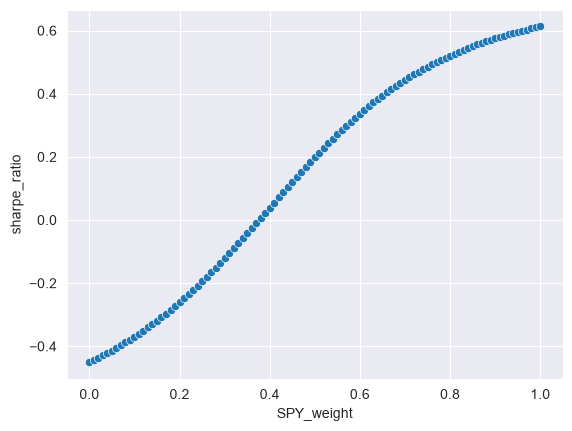

In [71]:
sns.scatterplot(
    data = results,
    x = 'SPY_weight',
    y = 'sharpe_ratio'
)

<Axes: xlabel='annual_volatility', ylabel='annual_mean'>

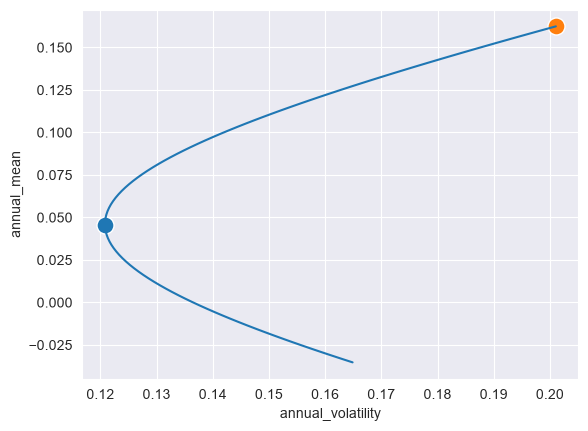

In [72]:
fig = sns.lineplot(
    data=results,
    x='annual_volatility',
    y='annual_mean',
    sort=False
)
sns.scatterplot(
    data = results.loc[[portfolio_min_annual_volatility]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)
sns.scatterplot(
    data = results.loc[[portfolio_max_sharpe]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)

<Axes: xlabel='annual_volatility', ylabel='annual_mean'>

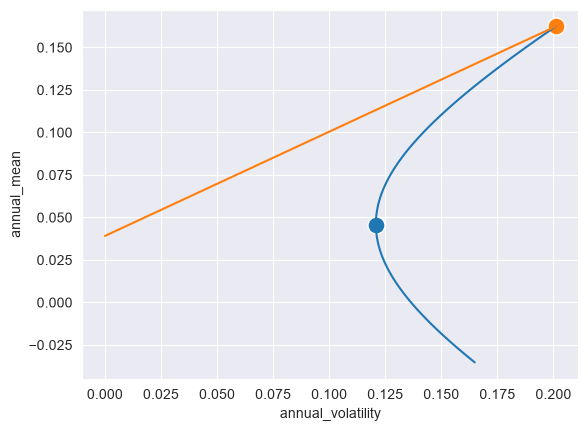

In [73]:
fig = sns.lineplot(
    data=results,
    x='annual_volatility',
    y='annual_mean',
    sort=False
)
sns.scatterplot(
    data = results.loc[[portfolio_min_annual_volatility]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)
sns.scatterplot(
    data = results.loc[[portfolio_max_sharpe]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)
sns.lineplot(
    data=pd.DataFrame({
        'annual_volatility': [0, results['annual_volatility'].loc[results['sharpe_ratio'].idxmax()]],
        'annual_mean': [risk_free_rate, results['annual_mean'].loc[results['sharpe_ratio'].idxmax()]]
    }),
    x='annual_volatility',
    y='annual_mean',
    ax=fig
)

In [74]:
y = np.linspace(0, 1.5, 151)

In [75]:
df_y = pd.DataFrame({
    'annual_volatility': y * results['annual_volatility'].loc[portfolio_max_sharpe],
    'annual_mean': risk_free_rate + y * (results['annual_mean'].loc[portfolio_max_sharpe] - risk_free_rate)
})

<Axes: xlabel='annual_volatility', ylabel='annual_mean'>

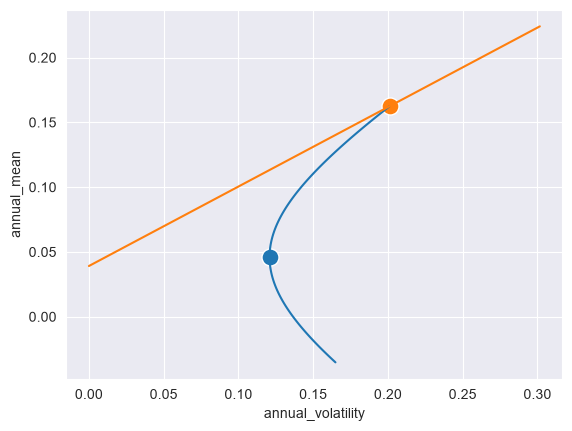

In [76]:
fig = sns.lineplot(
    data=results,
    x='annual_volatility',
    y='annual_mean',
    sort=False
)
sns.scatterplot(
    data = results.loc[[portfolio_min_annual_volatility]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)
sns.scatterplot(
    data = results.loc[[portfolio_max_sharpe]],
    x='annual_volatility',
    y='annual_mean',
    s=150,
    ax=fig
)
sns.lineplot(
    data=df_y,
    x='annual_volatility',
    y='annual_mean',
    ax=fig
)

In [77]:
annual_mean_returns = returns.mean() * 252
annual_cov_matrix = returns.cov() * 252
weights = np.ones(5) * 0.2

In [78]:
weights @ annual_mean_returns

np.float64(0.09441802468439361)

In [79]:
np.sqrt(weights @ annual_cov_matrix @ weights)

np.float64(0.13520985850327463)

In [80]:
(weights @ annual_mean_returns - risk_free_rate) / np.sqrt(weights @ annual_cov_matrix @ weights)

np.float64(0.4089052693960135)

In [81]:
weights = np.random.dirichlet(
    np.ones(len(annual_mean_returns))
)

In [82]:
weights

array([0.43264315, 0.08211192, 0.16520138, 0.16550211, 0.15454144])

In [83]:
portfolio_return = weights @ annual_mean_returns
portfolio_volatility = np.sqrt(weights @ annual_cov_matrix @ weights)
portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

In [84]:
portfolio_return, portfolio_volatility, portfolio_sharpe

(np.float64(0.09120807499789502),
 np.float64(0.15602097514948285),
 np.float64(0.3337889272893216))

In [85]:
annual_mean_returns.index

Index(['EEM', 'GLD', 'SPY', 'TLT', 'VNQ'], dtype='str', name='Ticker')

In [86]:
annual_cov_matrix.index

Index(['EEM', 'GLD', 'SPY', 'TLT', 'VNQ'], dtype='str', name='Ticker')

In [87]:
annual_cov_matrix.columns

Index(['EEM', 'GLD', 'SPY', 'TLT', 'VNQ'], dtype='str', name='Ticker')

In [88]:
n_portfolios = 10_000

In [89]:
portfolio_results = pd.DataFrame(columns=['EEM_weight', 'GLD_weight', 'SPY_weight', 'TLT_weight', 'VNQ_weight', 'annual_return', 'annual_volatility', 'sharpe_ratio'])

In [90]:
portfolio_results

,EEM_weight,GLD_weight,SPY_weight,TLT_weight,VNQ_weight,annual_return,annual_volatility,sharpe_ratio


In [91]:
assets = len(annual_mean_returns)

In [92]:
for i in range(n_portfolios):
    weights = np.random.dirichlet(
        np.ones(assets)
    )
    
    portfolio_return = weights @ annual_mean_returns
    portfolio_volatility = np.sqrt(weights @ annual_cov_matrix @ weights)
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    portfolio_results.loc[i] = [weights[0], weights[1], weights[2], weights[3], weights[4], portfolio_return, portfolio_volatility, portfolio_sharpe]

In [93]:
portfolio_results

,EEM_weight,GLD_weight,SPY_weight,TLT_weight,VNQ_weight,annual_return,annual_volatility,sharpe_ratio
0,0.086740,0.081631,0.021180,0.330600,0.479849,0.048291,0.143895,0.063665
1,0.101910,0.409533,0.321514,0.089214,0.077829,0.134843,0.136455,0.701424
2,0.112642,0.298303,0.047877,0.100977,0.440201,0.097506,0.150251,0.388522
3,0.073475,0.043224,0.058490,0.585858,0.238954,0.020609,0.125031,-0.148133
4,0.070950,0.140252,0.369275,0.345042,0.074481,0.084321,0.121048,0.373333
...,...,...,...,...,...,...,...,...
9995,0.179417,0.422402,0.052338,0.305791,0.040052,0.091178,0.123736,0.420640
9996,0.191176,0.006965,0.306356,0.162868,0.332635,0.088524,0.164790,0.299737
9997,0.339239,0.101076,0.024088,0.100980,0.434618,0.083531,0.168310,0.263803
9998,0.039942,0.204074,0.372658,0.247705,0.135620,0.100163,0.127124,0.480108


<Axes: xlabel='annual_volatility', ylabel='annual_return'>

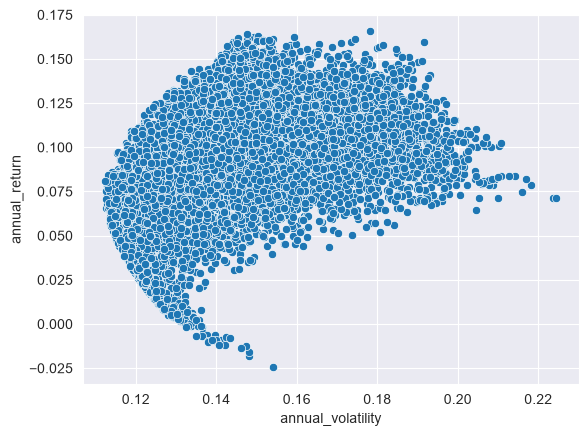

In [94]:
sns.scatterplot(
    data = portfolio_results,
    x = 'annual_volatility',
    y = 'annual_return'
)

In [95]:
min_volatility_idx = portfolio_results['annual_volatility'].idxmin()

In [96]:
max_sharpe_idx = portfolio_results['sharpe_ratio'].idxmax()

In [97]:
portfolio_results.iloc[min_volatility_idx]

EEM_weight           0.006838
GLD_weight           0.246502
SPY_weight           0.321455
TLT_weight           0.416875
VNQ_weight           0.008331
annual_return        0.080728
annual_volatility    0.112428
sharpe_ratio         0.369999
Name: 9301, dtype: float64

In [98]:
portfolio_results.iloc[max_sharpe_idx]

EEM_weight           0.035957
GLD_weight           0.624232
SPY_weight           0.327927
TLT_weight           0.000425
VNQ_weight           0.011458
annual_return        0.163947
annual_volatility    0.147704
sharpe_ratio         0.845048
Name: 7598, dtype: float64

<Axes: xlabel='annual_volatility', ylabel='annual_return'>

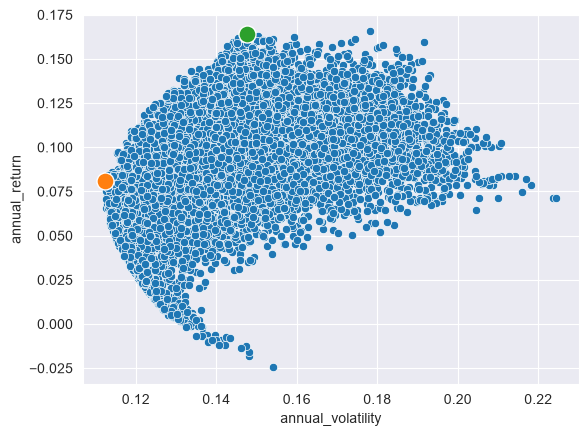

In [99]:
sns.scatterplot(
    data = portfolio_results,
    x = 'annual_volatility',
    y = 'annual_return'
)
sns.scatterplot(
    data = portfolio_results.loc[[min_volatility_idx]],
    x = 'annual_volatility',
    y = 'annual_return',
    s = 150
)
sns.scatterplot(
    data = portfolio_results.loc[[max_sharpe_idx]],
    x = 'annual_volatility',
    y = 'annual_return',
    s = 150
)

In [100]:
from scipy.optimize import minimize

In [101]:
def portfolio_variance(weights):
    return weights @ annual_cov_matrix @ weights

initial_weights = np.ones(assets) / assets

bounds = [(0, 1)] * assets

constraints = {
    'type': 'eq',
    'fun': lambda weights: sum(weights) - 1
}

result = minimize(
    portfolio_variance,
    initial_weights,
    method = 'SLSQP',
    bounds = bounds,
    constraints = constraints
)

In [102]:
result.success

True

In [103]:
result.fun

np.float64(0.01257901411173826)

In [104]:
result.x

array([1.44346129e-17, 2.34796000e-01, 3.15757726e-01, 4.49446274e-01,
       9.84801735e-18])

In [105]:
result.x.sum()

np.float64(1.0)

In [106]:
target_return = 0.1

constraints = [
    {
        'type': 'eq',
        'fun': lambda weights: np.sum(weights) - 1
    },
    {
        'type': 'eq',
        'fun': lambda weights, target_return=target_return: (
                weights @ annual_mean_returns - target_return
        )
    }
]

In [107]:
result_target = minimize(
    portfolio_variance,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

In [108]:
result_target.success

True

In [109]:
result_target.x

array([1.73535069e-17, 3.21775707e-01, 3.50072904e-01, 3.28151389e-01,
       1.27504656e-17])

In [110]:
result_target.x.sum()

np.float64(1.0)

In [111]:
result_target.x @ annual_mean_returns

np.float64(0.09999999999731442)

In [112]:
np.sqrt(result_target.fun)

np.float64(0.1149708968705519)

In [113]:
min_var_weights = minimize(
    portfolio_variance,
    initial_weights,
    method = 'SLSQP',
    bounds = bounds,
    constraints = {
    'type': 'eq',
    'fun': lambda weights: sum(weights) - 1
    }
).x

In [114]:
min_var_return = min_var_weights @ annual_mean_returns

In [115]:
max_return = annual_mean_returns.max()

In [116]:
target_returns = np.linspace(
    min_var_return,
    max_return,
    50
)

In [117]:
portfolio_results_curve = pd.DataFrame(columns=['EEM_weight', 'GLD_weight', 'SPY_weight', 'TLT_weight', 'VNQ_weight', 'annual_return', 'annual_volatility', 'sharpe_ratio'])

In [118]:
for i, target_return in enumerate(target_returns):
    constraints = [
        {
            'type': 'eq',
            'fun': lambda weights: np.sum(weights) - 1
        },
        {
            'type': 'eq',
            'fun': lambda weights, target_return=target_return: (
                    weights @ annual_mean_returns - target_return
            )
        }
    ]
    
    
    result_target = minimize(
        portfolio_variance,
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )
    
    portfolio_return = result_target.x @ annual_mean_returns
    portfolio_volatility = np.sqrt(result_target.fun)
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
    
    if not result_target.success:
        print(target_return, result_target.message)
    
    portfolio_results_curve.loc[i] = [result_target.x[0], result_target.x[1], result_target.x[2], result_target.x[3], result_target.x[4], portfolio_return, portfolio_volatility, portfolio_sharpe]

In [119]:
portfolio_results_curve

,EEM_weight,GLD_weight,SPY_weight,TLT_weight,VNQ_weight,annual_return,annual_volatility,sharpe_ratio
0,7.034782e-03,0.233551,3.120571e-01,0.447357,0.000000e+00,0.075365,0.112164,0.323053
1,5.131890e-03,0.240180,3.162946e-01,0.438393,0.000000e+00,0.077296,0.112185,0.340208
2,5.314008e-04,0.245207,3.241110e-01,0.430151,6.761783e-18,0.079227,0.112230,0.357280
3,2.777028e-04,0.252674,3.263073e-01,0.420741,3.812832e-18,0.081159,0.112316,0.374199
4,0.000000e+00,0.260588,3.280572e-01,0.411354,0.000000e+00,0.083090,0.112437,0.390973
5,0.000000e+00,0.268787,3.293145e-01,0.401898,5.752016e-19,0.085021,0.112594,0.407580
6,1.301043e-17,0.277506,3.300316e-01,0.392462,5.961118e-18,0.086952,0.112788,0.424004
7,0.000000e+00,0.284723,3.323084e-01,0.382969,0.000000e+00,0.088884,0.113014,0.440242
8,0.000000e+00,0.290532,3.360465e-01,0.373421,7.419311e-19,0.090815,0.113273,0.456284
9,3.035766e-18,0.298246,3.378068e-01,0.363947,0.000000e+00,0.092746,0.113569,0.472103


<Axes: xlabel='annual_volatility', ylabel='annual_return'>

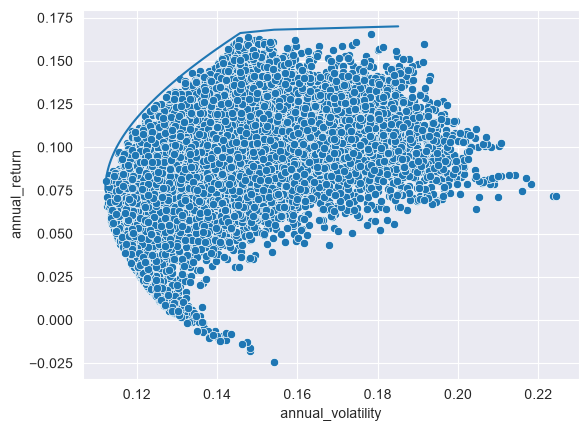

In [120]:
fig = sns.scatterplot(
    data=portfolio_results,
    x='annual_volatility',
    y='annual_return'
)
sns.lineplot(
    data=portfolio_results_curve,
    x='annual_volatility',
    y='annual_return',
    sort=True,
    ax=fig
)

In [121]:
min_var_weights = result.x
min_var_return = min_var_weights @ annual_mean_returns
min_var_volatility = np.sqrt(result.fun)

<Axes: xlabel='annual_volatility', ylabel='annual_return'>

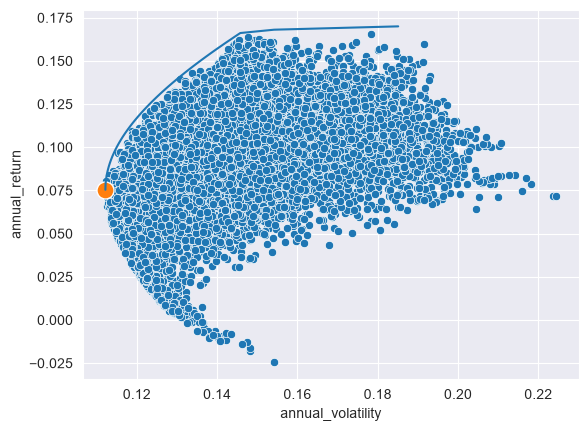

In [122]:
fig = sns.scatterplot(
    data=portfolio_results,
    x='annual_volatility',
    y='annual_return'
)

sns.lineplot(
    data=portfolio_results_curve,
    x='annual_volatility',
    y='annual_return',
    sort=True,
    ax=fig
)

sns.scatterplot(
    x=[min_var_volatility],
    y=[min_var_return],
    s=150,
    ax=fig
)

In [123]:
def negative_sharpe(weights):
    portfolio_return = weights @ annual_mean_returns
    portfolio_volatility = np.sqrt(
        weights @ annual_cov_matrix @ weights
    )

    return -(
        (portfolio_return - risk_free_rate)
        / portfolio_volatility
    )

In [124]:
constraints_max_sharpe = {
    'type': 'eq',
    'fun': lambda weights: np.sum(weights) - 1
}

In [125]:
result_max_sharpe = minimize(
    negative_sharpe,
    initial_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_max_sharpe
)

In [126]:
result_max_sharpe.success

True

In [127]:
result_max_sharpe.x

array([7.30408966e-17, 5.68617605e-01, 4.31382395e-01, 6.55372233e-17,
       1.44821177e-16])

In [128]:
result_max_sharpe.x.sum()

np.float64(1.0000000000000002)

In [129]:
-result_max_sharpe.fun

np.float64(0.8729496347372279)

In [130]:
max_sharpe_weights = result_max_sharpe.x

max_sharpe_return = (
    max_sharpe_weights @ annual_mean_returns
)

max_sharpe_volatility = np.sqrt(
    max_sharpe_weights
    @ annual_cov_matrix
    @ max_sharpe_weights
)

max_sharpe_ratio = -result_max_sharpe.fun

<Axes: xlabel='annual_volatility', ylabel='annual_return'>

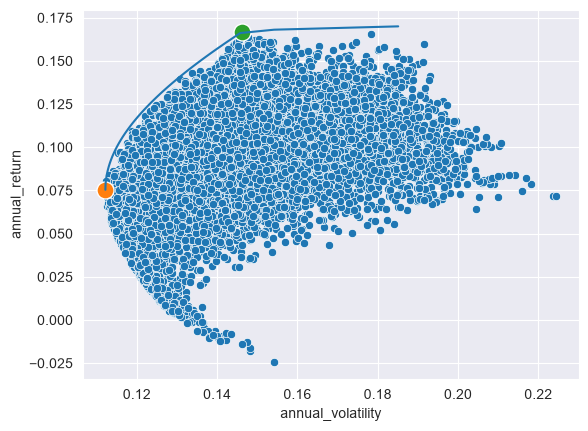

In [131]:
fig = sns.scatterplot(
    data=portfolio_results,
    x='annual_volatility',
    y='annual_return'
)

sns.lineplot(
    data=portfolio_results_curve,
    x='annual_volatility',
    y='annual_return',
    sort=True,
    ax=fig
)

sns.scatterplot(
    x=[min_var_volatility],
    y=[min_var_return],
    s=150,
    ax=fig
)

sns.scatterplot(
    x=[max_sharpe_volatility],
    y=[max_sharpe_return],
    s=150,
    ax=fig
)

In [132]:
max_sharpe_weights

array([7.30408966e-17, 5.68617605e-01, 4.31382395e-01, 6.55372233e-17,
       1.44821177e-16])

In [133]:
max_sharpe_return

np.float64(0.1667348348276984)

In [134]:
max_sharpe_volatility

np.float64(0.1461766277020029)

In [135]:
max_sharpe_ratio

np.float64(0.8729496347372279)

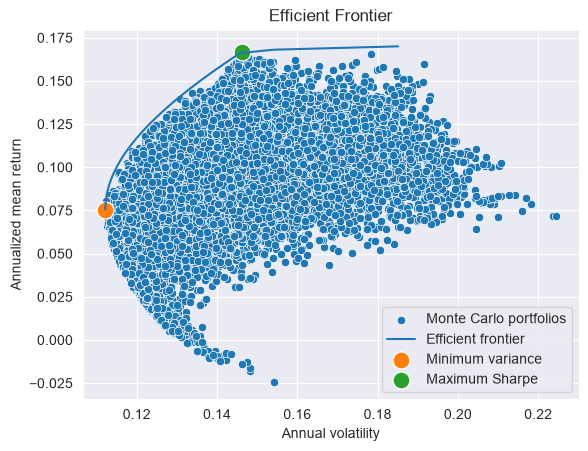

In [136]:
fig = sns.scatterplot(
    data=portfolio_results,
    x='annual_volatility',
    y='annual_return',
    label='Monte Carlo portfolios'
)

sns.lineplot(
    data=portfolio_results_curve,
    x='annual_volatility',
    y='annual_return',
    sort=True,
    ax=fig,
    label='Efficient frontier'
)

sns.scatterplot(
    x=[min_var_volatility],
    y=[min_var_return],
    s=150,
    ax=fig,
    label='Minimum variance'
)

sns.scatterplot(
    x=[max_sharpe_volatility],
    y=[max_sharpe_return],
    s=150,
    ax=fig,
    label='Maximum Sharpe'
)

fig.set(
    xlabel='Annual volatility',
    ylabel='Annualized mean return',
    title='Efficient Frontier'
)

fig.legend()

In [137]:
max_sharpe_daily_returns = returns @ max_sharpe_weights

In [138]:
confidence_level = 0.95
var_threshold = max_sharpe_daily_returns.quantile(1 - confidence_level)
historical_var = - var_threshold

In [139]:
var_threshold

np.float64(-0.01362282560155622)

In [140]:
historical_var

np.float64(0.01362282560155622)

In [141]:
tail_returns = max_sharpe_daily_returns[
    max_sharpe_daily_returns <= var_threshold
]

In [143]:
historical_cvar = - tail_returns.mean()

In [144]:
historical_cvar

np.float64(0.021866141409692168)

In [147]:
from scipy.stats import norm

In [149]:
mu = max_sharpe_daily_returns.mean()
sigma = max_sharpe_daily_returns.std()
z = norm.ppf(1 - confidence_level)

In [151]:
parametric_var_threshold = mu + z * sigma
parametric_var = - parametric_var_threshold

In [152]:
parametric_var

np.float64(0.014484596993925219)

In [153]:
alpha = 1 - confidence_level

In [154]:
parametric_cvar = - (mu - sigma * norm.pdf(z) / alpha)

In [156]:
parametric_cvar

np.float64(0.018332353811465637)

In [170]:
(max_sharpe_daily_returns + 1).cumprod() / (max_sharpe_daily_returns + 1).cumprod().cummax() - 1

Date
2020-01-03    0.000000
2020-01-06    0.000000
2020-01-07    0.000000
2020-01-08   -0.001966
2020-01-09   -0.002254
                ...   
2026-09-04   -0.057252
2026-09-08   -0.068777
2026-09-09   -0.065835
2026-09-10   -0.077456
2026-09-11   -0.070874
Length: 1681, dtype: float64

In [177]:
max_sharpe_cumulative = (max_sharpe_daily_returns + 1).cumprod()
max_sharpe_running_max = max_sharpe_cumulative.cummax()
max_sharpe_drawdown = max_sharpe_running_max / max_sharpe_cumulative - 1
max_sharpe_max_drawdown = max_sharpe_drawdown.max()

In [178]:
risk_summary = pd.DataFrame({
    'value': [
        max_sharpe_return,
        max_sharpe_volatility,
        max_sharpe_ratio,
        max_sharpe_max_drawdown,
        historical_var,
        historical_cvar,
        parametric_var,
        parametric_cvar
    ]
}, index=[
    'Annual return',
    'Annual volatility',
    'Sharpe ratio',
    'Max drawdown',
    'Historical VaR 95%',
    'Historical CVaR 95%',
    'Parametric VaR 95%',
    'Parametric CVaR 95%'
])

In [181]:
risk_summary.to_clipboard()